<a href="https://colab.research.google.com/github/RamenIQ/CSES-Innovate-Demo/blob/main/MTC_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"Training samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")

Training samples: 455, Features: 30


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def sigmoid_derivative(a):
    return a * (1 - a)
def relu(z):
    return np.maximum(0, z)
def relu_derivative(z):
    return (z > 0).astype(float)

In [6]:
def initialize_network(layer_sizes):
    np.random.seed(42)
    params = []
    for i in range(len(layer_sizes) - 1):
        w = np.random.randn(layer_sizes[i], layer_sizes[i + 1])
        b = np.zeros((1, layer_sizes[i + 1]))
        params.append((w, b))
    return params

In [7]:
def forward(X, params):
    activations = [X]

    for i, (w, b) in enumerate(params):
        z = activations[-1] @ w + b

        if i == len(params) - 1:
            a = sigmoid(z)
        else:
            a = relu(z)
        activations.append(a)
    return activations

In [8]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [9]:
def backward(y, activations, params):
    m = y.shape[0]
    grads = []

    delta = activations[-1] - y

    for i in reversed(range(len(params))):
        a_prev = activations[i]
        dw = (a_prev.T @ delta) / m
        db = np.sum(delta, axis = 0, keepdims = True) / m
        grads.insert(0, (dw, db))

        if i > 0:
            delta = (delta @ params[i][0].T) * relu_derivative(activations[i])
    return grads

In [10]:
def update_params(params, grads, learning_rate):
    new_params = []
    for (w,b), (dw, db) in zip(params, grads):
        w = w - learning_rate * dw
        b = b - learning_rate * db
        new_params.append((w, b))
    return new_params

In [11]:
def train(X_train, y_train, layer_sizes, epochs=500, learning_rate=0.1):
    params = initialize_network(layer_sizes)
    losses = []

    for epoch in range(epochs):
        activations = forward(X_train, params)
        loss = binary_cross_entropy(y_train, activations[-1])
        losses.append(loss)
        grads = backward(y_train, activations, params)
        params = update_params(params, grads, learning_rate)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: loss = {loss:.4f}")
    return params, losses

In [12]:
n_features = X_train.shape[1]
layer_sizes = [n_features, 16, 1]
params, losses = train(X_train, y_train, layer_sizes, epochs = 500, learning_rate = 0.1)

def predict(X, params):
    activations = forward(X, params)
    predictions = (activations[-1] >= 0.5).astype(int)
    return predictions
y_pred = predict(X_test, params)
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy * 100:.1f}%")

Epoch 0: loss = 1.0264
Epoch 50: loss = 0.1211
Epoch 100: loss = 0.0890
Epoch 150: loss = 0.0741
Epoch 200: loss = 0.0644
Epoch 250: loss = 0.0573
Epoch 300: loss = 0.0516
Epoch 350: loss = 0.0468
Epoch 400: loss = 0.0427
Epoch 450: loss = 0.0390
Test Accuracy: 94.7%


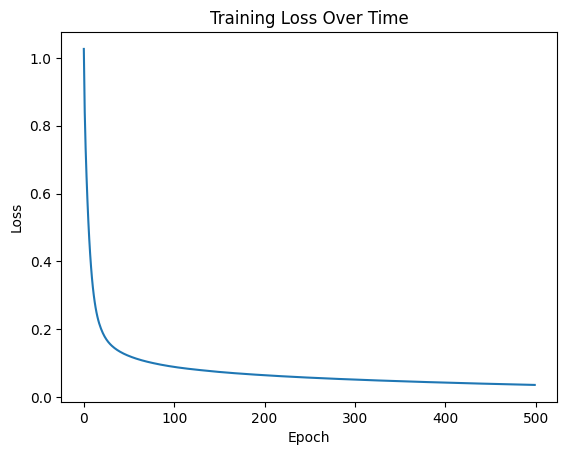

In [13]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.show()